# Introduction
let's say we have a 2ls with 
$$\hat{H} = \frac{\omega}{2}\hat{\sigma}_z$$
With some losses (dissipator is $\hat{\sigma}^-$).\\
If we start from $\ket{\psi_0} = \ket{e}$, by simulating the system with quantum jumpt trajectories, at a certain point we observe spontaneous emission -> $P_e$ will be like a step function. 
What happens if $\ket{\psi_0} = \frac{1}{\sqrt{2}}(\ket{g}+\ket{e})$?


In [1]:
using Pkg
Pkg.activate("/home/camilla/tp4spring/julia") # change to your path
Pkg.status()

  Activating project at `~/tp4spring/julia`


Status `~/tp4spring/julia/Project.toml`
⌃ [6e4b80f9] BenchmarkTools v1.6.3
  [13f3f980] CairoMakie v0.15.9
  [7a1cc6ca] FFTW v1.10.0
  [7073ff75] IJulia v1.34.4
⌃ [1dea7af3] OrdinaryDiffEq v6.108.0
  [6c2fb7c5] QuantumToolbox v0.44.0
⌃ [789caeaf] StochasticDiffEq v6.100.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [30]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

# Hamiltonian
ω = 1.0
H = ω/2 * sigmaz()

# Jump operator
L = sigmam()
gamma = 0.01;

[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 1.74 μs/it)
[mcsolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.77 ms/it)
[mcsolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.11 ms/it)


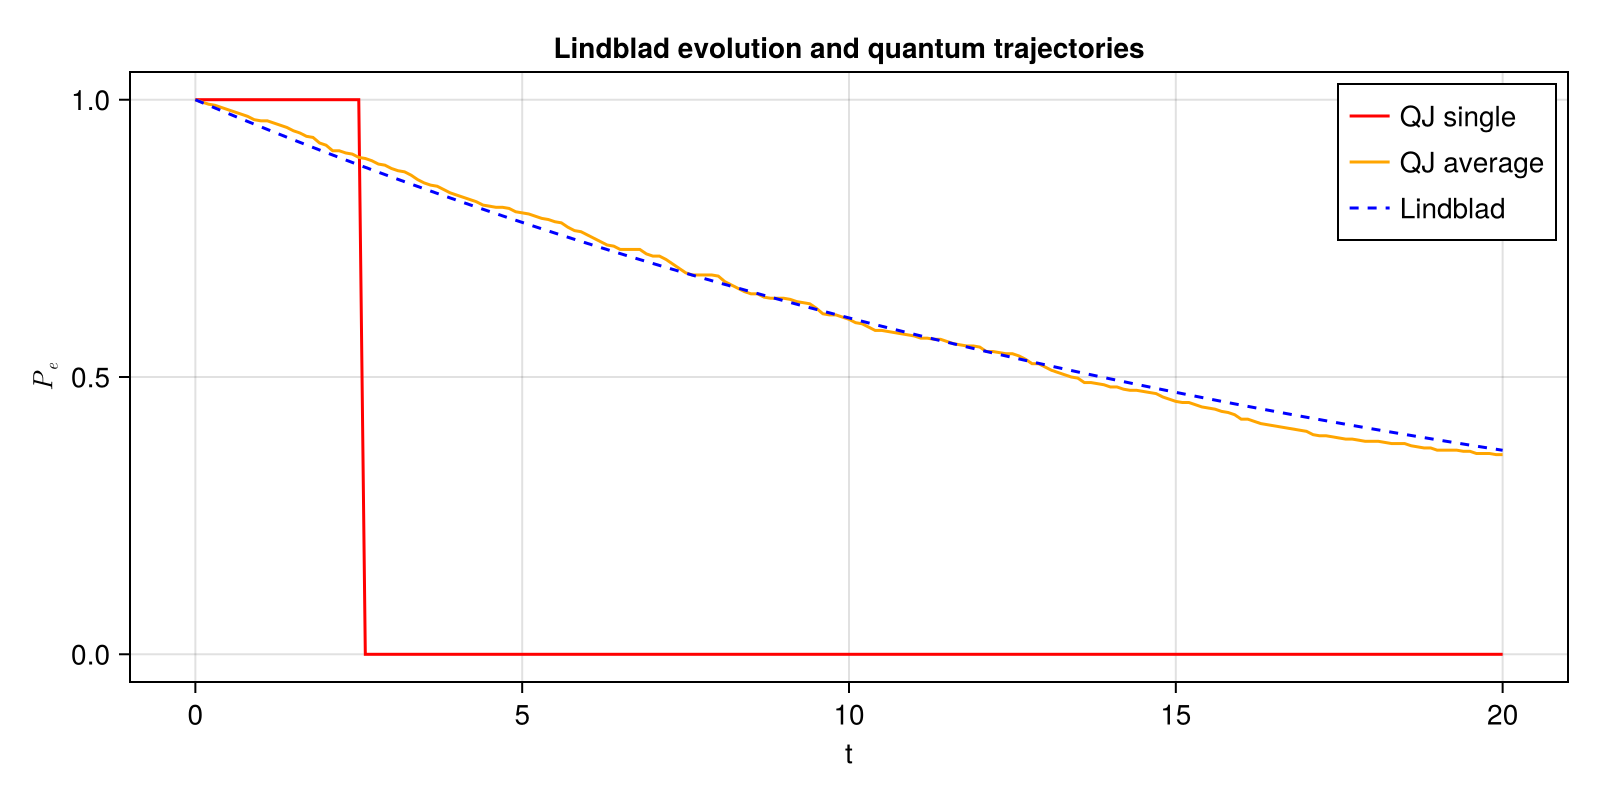

In [21]:
#single trajectory, me evolution, monte carlo wavefunction method
e_ops = [sigmaz()]
ψ0 = basis(2, 0) #initial state |e>
tlist = 0:0.1:20

result = mesolve(H, ψ0, tlist, [sqrt(gamma)*L]; e_ops=e_ops)
Z_lind = real.(result.expect[1, :])

single_qj = mcsolve(H, ψ0, tlist, [sqrt(gamma)*L]; e_ops=e_ops, ntraj=1)
Z_qj_single = real.(single_qj.expect[1, :])

sol_qj = mcsolve(H, ψ0, tlist, [sqrt(gamma)*L]; e_ops=e_ops, ntraj=500)
Z_qj = real.(sol_qj.expect[1, :])

fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1],
    xlabel = "t",
    ylabel = L"$P_e$",
    title = "Lindblad evolution and quantum trajectories"
)

lines!(ax, tlist, (Z_qj_single .+ 1)./2, color = :red, label = "QJ single")
lines!(ax, tlist, (Z_qj .+ 1)./2, color = :orange, label = "QJ average")
lines!(ax, tlist, (Z_lind .+ 1)./2, color = :blue, linestyle = :dash, label = "Lindblad")
axislegend(ax, position = :rt)

fig


Quantum Object:   type=Ket()   dims=([2], [1])   size=(2,)
2-element Vector{ComplexF64}:
 0.7071067811865475 + 0.0im
 0.7071067811865475 + 0.0im

[mesolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.51 μs/it)
[mcsolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.41 ms/it)
[mcsolve] 100%|███████████████████████████| Time: 0:00:00 ( 0.17 ms/it)


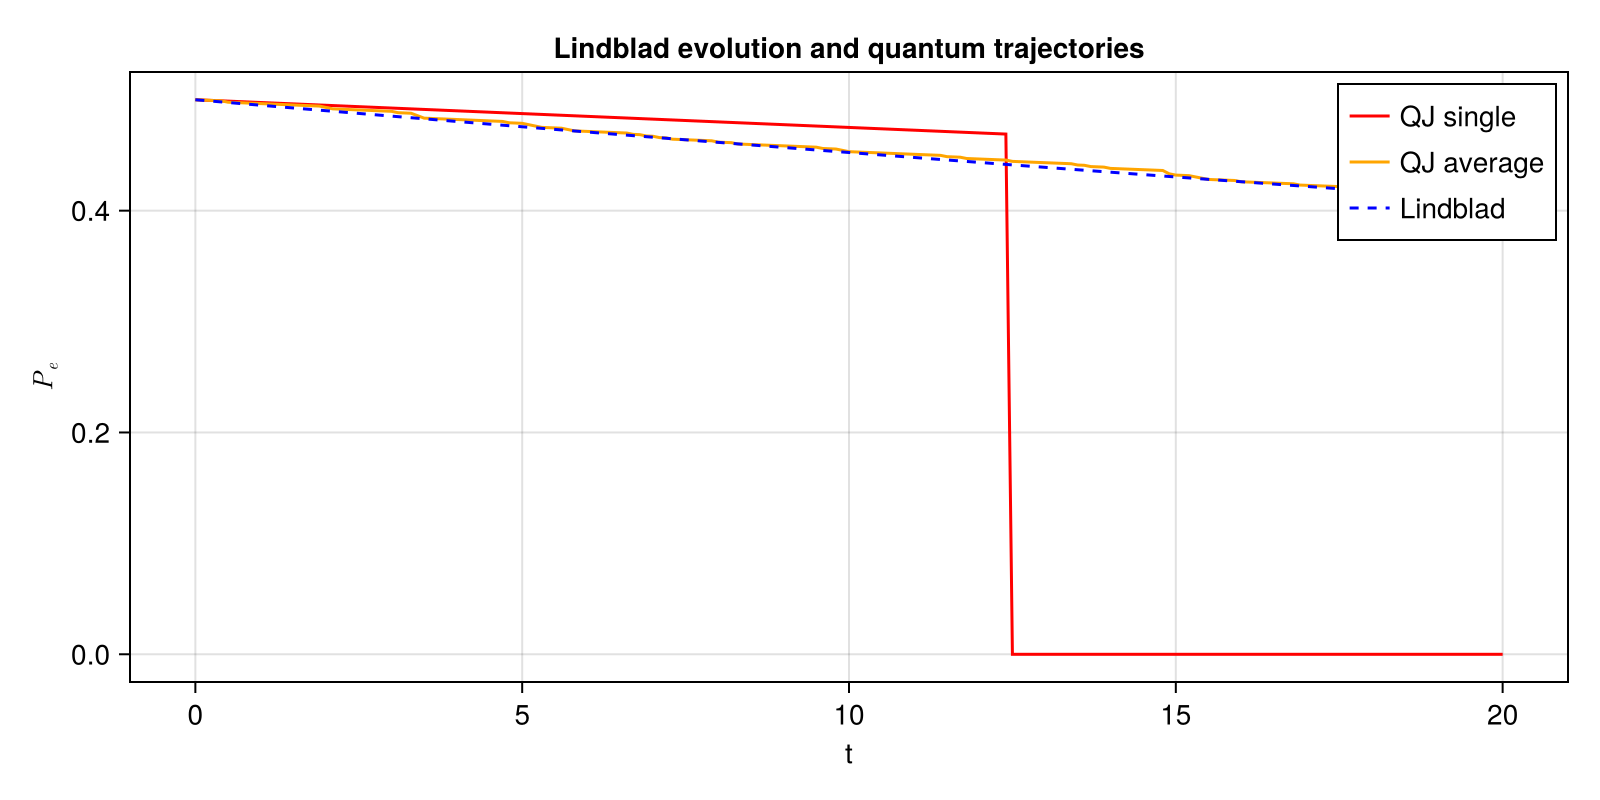

In [34]:
psi0 = basis(2, 0) + basis(2, 1)
psi0 = psi0 / norm(psi0)
display(psi0)
result = mesolve(H, psi0, tlist, [sqrt(gamma)*L]; e_ops=e_ops)
Z_lind = real.(result.expect[1, :])

single_qj = mcsolve(H, psi0, tlist, [sqrt(gamma)*L]; e_ops=e_ops, ntraj=1)
Z_qj_single = real.(single_qj.expect[1, :])

sol_qj = mcsolve(H, psi0, tlist, [sqrt(gamma)*L]; e_ops=e_ops, ntraj=500)
Z_qj = real.(sol_qj.expect[1, :])

fig2 = Figure(size = (800, 400))
ax2 = Axis(fig2[1, 1],
    xlabel = "t",
    ylabel = L"$P_e$",
    title = "Lindblad evolution and quantum trajectories"
)

lines!(ax2, tlist, (Z_qj_single .+ 1)./2, color = :red, label = "QJ single")
lines!(ax2, tlist, (Z_qj .+ 1)./2, color = :orange, label = "QJ average")
lines!(ax2, tlist, (Z_lind .+ 1)./2, color = :blue, linestyle = :dash, label = "Lindblad")
axislegend(ax2, position = :rt)

fig2

When no jump occurrs, the system evolves under the effective Hamiltonian:

$\hat{H}_{eff} = \hat{H} - \frac{i}{2} \gamma \hat{\sigma}^+ \hat{\sigma}^- $ , 
the non hermitian component acts on the excited state, so that the amplitude is decaying. So as time passes, the probability of being in $\ket{e}$ becomes lower and lower -> we gain information even when the detector is not clicking